# Projeto CardioIA - Visão Computacional (Fase 4)
## Parte 1: Pré-processamento e Organização das Imagens
## Parte 2: Classificação de Imagens Médicas com CNN e Transfer Learning Otimizado

Importação das Bibliotecas

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
BASE_DIR = r"C:\Users\Fran\Nova pasta\fiap-fase4\dataset_estruturado"

Carregamento dos Datasets via TensorFlow API

In [ ]:
# Resolução expandida para 256x256 para reter detalhes anatômicos sutis
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Salva a lista de classes globalmente
class_names = train_ds.class_names
print(f"Classes detectadas em disco: {class_names}\n")

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False  # Mantido False para não desalinhá-lo com o relatório de métricas
)

🔄 Carregando subconjuntos de imagens direto do diretório estruturado...
Found 2620 files belonging to 3 classes.
📌 Classes detectadas em disco: ['Cardiomegalia', 'Infiltrado', 'Saudavel']

Found 561 files belonging to 3 classes.
Found 564 files belonging to 3 classes.


Ativação do Prefetching (Otimização de Memória)

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Inspeção Visual das Imagens

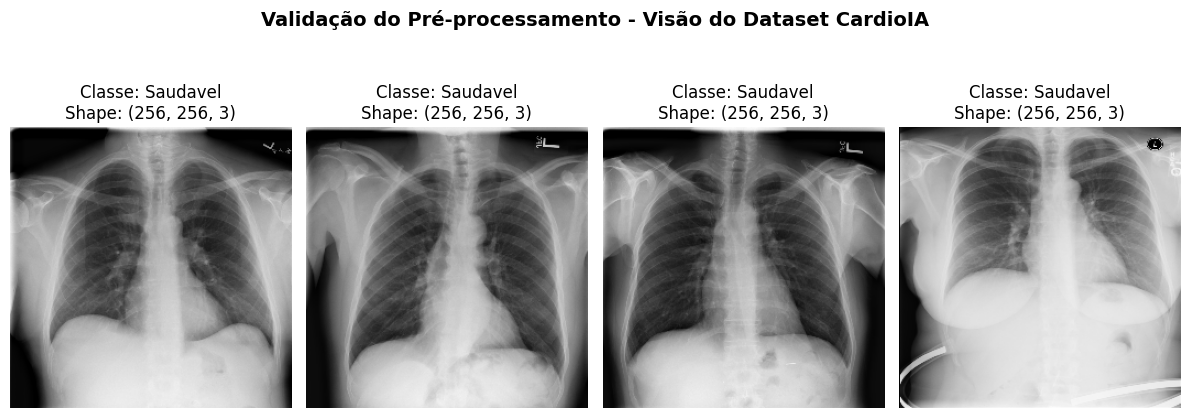

Valor de Pixel Máximo: 255.0 | Mínimo: 0.0


In [5]:
for images_batch, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 5))
    for i in range(min(4, len(images_batch))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels_batch[i])
        plt.title(f"Classe: {class_names[label_idx]}\nShape: {images_batch[i].shape}")
        plt.axis('off')

    plt.suptitle("Validação do Pré-processamento - Visão do Dataset CardioIA", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Valor de Pixel Máximo: {images_batch.numpy().max()} | Mínimo: {images_batch.numpy().min()}")

## PARTE 2 - Classificação de Imagens Médicas com CNN
### Abordagem 1: Arquitetura CNN Desenvolvida do Zero (Baseline)

In [13]:
# Data Augmentation ligeiramente mais suave para não deformar o tamanho do coração
data_augmentation_suave = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05), # Rotação menor para proteger a anatomia
    layers.RandomZoom(0.05),     # Zoom menor para não distorcer a Cardiomegalia
    layers.RandomContrast(0.15)
])

# Estrutura de 3 blocos (Consolidando o que funcionou melhor)
model_do_zero = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation_suave,
    layers.Rescaling(1./255),
    
    # Bloco Convolucional 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco Convolucional 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco Convolucional 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # O PULO DO GATO: Global Average Pooling em vez de Flatten para mapear texturas sem dar overfitting
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

model_do_zero.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Começa com LR padrão
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_do_zero.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,555 (435.76 KB)

 Trainable params: 110,851 (433.01 KB)

 Non-trainable params: 704 (2.75 KB)

Treinamento da CNN do Zero

In [ ]:
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
train_labels_indices = np.argmax(train_labels, axis=1)
classes_finais = np.unique(train_labels_indices)

pesos_calculados = compute_class_weight(
    class_weight='balanced', 
    classes=classes_finais, 
    y=train_labels_indices
)
class_weight_dict = dict(zip(classes_finais, pesos_calculados))
print(f"Pesos aplicados: {class_weight_dict}")
# Callbacks dinâmicos para a CNN do Zero
early_stopping_zero = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lr_reducer_zero = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

history_zero = model_do_zero.fit(
    train_ds,
    epochs=15, 
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_zero, lr_reducer_zero]
)

⚖️ 1. Computando pesos automáticos para a CNN do Zero...
Pesos aplicados: {np.int64(0): np.float64(6.374695863746958), np.int64(1): np.float64(1.5707434052757794), np.int64(2): np.float64(0.45320878740702303)}
🏋️ Treinando a CNN otimizada de 3 blocos...
Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.3519 - loss: 1.3148 - precision_2: 0.3395 - recall_2: 0.2088 - val_accuracy: 0.7166 - val_loss: 1.0415 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.3947 - loss: 1.2172 - precision_2: 0.4139 - recall_2: 0.2210 - val_accuracy: 0.0517 - val_loss: 1.2910 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3794 - loss: 1.1929 - precision_2: 0.4022 - recall_2: 0.2111
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
82/82 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accura

Métricas e Matriz de Confusão

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step


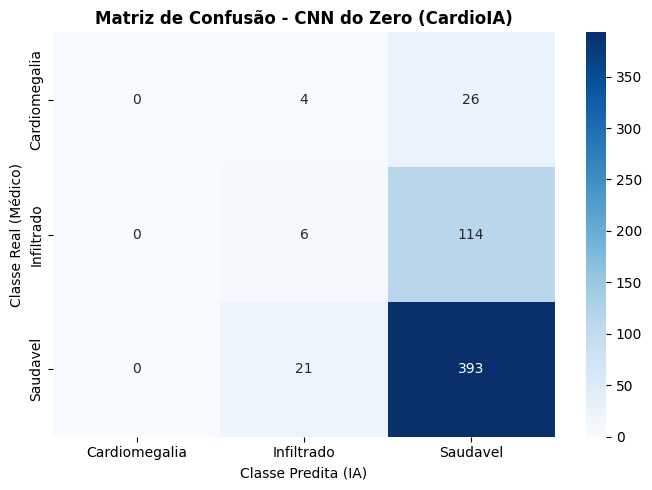


📋 --- RELATÓRIO DE MÉTRICAS (CNN DO ZERO) ---
               precision    recall  f1-score   support

Cardiomegalia       0.00      0.00      0.00        30
   Infiltrado       0.19      0.05      0.08       120
     Saudavel       0.74      0.95      0.83       414

     accuracy                           0.71       564
    macro avg       0.31      0.33      0.30       564
 weighted avg       0.58      0.71      0.63       564



c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [ ]:
predictions_zero = model_do_zero.predict(test_ds, verbose=1)
y_pred_zero = np.argmax(predictions_zero, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

cm_zero = confusion_matrix(y_true_indices, y_pred_zero)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_zero, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN do Zero (CardioIA)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n📋 --- RELATÓRIO DE MÉTRICAS (CNN) ---")
print(classification_report(y_true_indices, y_pred_zero, target_names=class_names))

### Abordagem 2: Transfer Learning de Alta Performance com ResNet50V2 e Fine-Tuning Corrigido

In [ ]:
base_model_densenet = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model_densenet.trainable = True
for layer in base_model_densenet.layers[:-50]: # Ponto de equilíbrio: 50 camadas
    layer.trainable = False

model_cardioia = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation_suave,
    layers.Lambda(tf.keras.applications.densenet.preprocess_input),
    
    base_model_densenet,
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

model_cardioia.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Aumentado de 1e-5 para 1e-4
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


🏗️ Ajustando parâmetros da DenseNet121...
🔥 DenseNet reconfigurada para quebrar o platô!


In [ ]:
# 1. Definição dos Callbacks Inteligentes de Treinamento
early_stopping_clinical = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,  # Tolerância estendida para permitir a superação de platôs de acurácia
    restore_best_weights=True
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   # Corta a taxa de aprendizado pela metade se a perda estagnar por 2 épocas
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_cardioia = model_cardioia.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weight_dict,  # Utiliza o dicionário automático calculado na abordagem 1
    callbacks=[early_stopping_clinical, lr_reducer],
    verbose=1
)



🏋️ 2. Disparando processamento das 20 épocas de refinamento clínico na DenseNet...
Epoch 1/20


82/82 ━━━━━━━━━━━━━━━━━━━━ 446s 5s/step - accuracy: 0.3733 - loss: 1.5238 - precision_3: 0.3816 - recall_3: 0.3279 - val_accuracy: 0.7130 - val_loss: 0.7033 - val_precision_3: 0.7598 - val_recall_3: 0.6542 - learning_rate: 1.0000e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.4118 - loss: 1.3261 - precision_3: 0.4244 - recall_3: 0.3565 - val_accuracy: 0.6702 - val_loss: 0.7680 - val_precision_3: 0.7384 - val_recall_3: 0.5686 - learning_rate: 1.0000e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4391 - loss: 1.2360 - precision_3: 0.4569 - recall_3: 0.3869
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
82/82 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.4359 - loss: 1.2363 - precision_3: 0.4457 - recall_3: 0.3821 - val_accuracy: 0.6096 - val_loss: 0.8627 - val_precision_3: 0.6390 - val_recall_3: 0.5080 - learning_rate: 1.0000e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.4531 - loss: 1.0994 - 

🔮 Computando predições para o conjunto de teste oculto...
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step


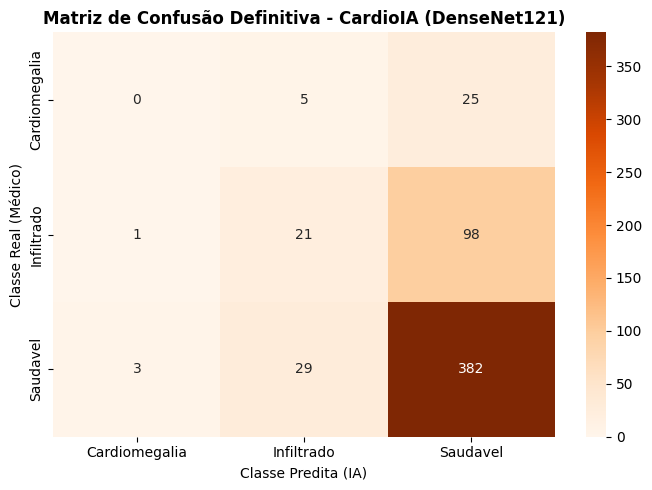


📋 --- RELATÓRIO DE MÉTRICAS DETALHADO (DENSENET121) ---
               precision    recall  f1-score   support

Cardiomegalia       0.00      0.00      0.00        30
   Infiltrado       0.38      0.17      0.24       120
     Saudavel       0.76      0.92      0.83       414

     accuracy                           0.71       564
    macro avg       0.38      0.37      0.36       564
 weighted avg       0.64      0.71      0.66       564



In [18]:
predictions_cardioia = model_cardioia.predict(test_ds, verbose=1)
y_pred_cardioia = np.argmax(predictions_cardioia, axis=1)

# Matriz de Confusão
cm_cardioia = confusion_matrix(y_true_indices, y_pred_cardioia)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_cardioia, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão Definitiva - CardioIA (DenseNet121)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n📋 --- RELATÓRIO DE MÉTRICAS (DENSENET121) ---")
print(classification_report(y_true_indices, y_pred_cardioia, target_names=class_names))

Exportação do Melhor Modelo para a Interface Flask

In [21]:
caminho_salvamento = r"C:\Users\Fran\cardio-ia\fase-4-visao-computacional\melhor_modelo_cardioia.h5"

# Salva a melhor rede convolucional
base_model_densenet.save(caminho_salvamento)